# 🔍 Mapping Pipeline — CIS v8 ↔ NIST CSF v2

Pipeline en 4 étapes pour mettre en correspondance deux référentiels de sécurité.

| Étape | Rôle | LLM |
|---|---|---|
| **1** | Structuration & normalisation | ❌ |
| **2** | Proximité sémantique sur titres → filtrer ~99% | ❌ |
| **3** | Matrice de corrélation (heatmap visuelle) | ❌ |
| **4** | Vérification intelligente LLM (titre + description) | ✅ |

## ⚙️ Configuration

In [18]:
%matplotlib inline
import sys, os
import matplotlib.pyplot as plt
from pathlib import Path
import dotenv
dotenv.load_dotenv()

# Chemin racine du projet
ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT))

# Fichiers sources
CIS_YAML  = ROOT / "files/surveys/cis-controls-v8-1.yaml"
NIST_YAML = ROOT / "files/surveys/nistCsfV2.yaml"

# Clé API OpenAI (uniquement nécessaire pour l'étape 4)
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

print(f"CIS  : {CIS_YAML.exists()} — {CIS_YAML}")
print(f"NIST : {NIST_YAML.exists()} — {NIST_YAML}")

CIS  : True — C:\RiskHunter\files\surveys\cis-controls-v8-1.yaml
NIST : True — C:\RiskHunter\files\surveys\nistCsfV2.yaml


---
## Étape 1 — Structuration & normalisation

Parse les fichiers YAML sources et produit des listes de `RequirementNormalized`  
(`id`, `framework`, `title`, `description`, `tags`).  
Résultats mis en cache dans `referential_mapping/data/`.

In [19]:
from referential_mapping.ingestion.adapters import cis_v8, nist_csf_v2
from referential_mapping.ingestion.ingester import run as ingest

ref_A, ref_B = ingest(
    path_A=str(CIS_YAML),  adapter_A=cis_v8,
    path_B=str(NIST_YAML), adapter_B=nist_csf_v2,
    # force=True  # décommenter pour re-parser depuis les sources
)

  [cache] ref_A_normalized.json
  [cache] ref_B_normalized.json
[Étape 1] Ref A : 153 exigences  |  Ref B : 106 exigences


In [20]:
import pandas as pd

df_A = pd.DataFrame([r.to_dict() for r in ref_A])
df_B = pd.DataFrame([r.to_dict() for r in ref_B])

print(f"Ref A (CIS v8)      : {len(df_A)} exigences")
print(f"Ref B (NIST CSF v2) : {len(df_B)} exigences")
df_A.head(5)

Ref A (CIS v8)      : 153 exigences
Ref B (NIST CSF v2) : 106 exigences


,id,framework,title,description,tags
0,CIS-1.1,CIS_v8,Établir et tenir à jour un inventaire détaillé...,"Établir et tenir à jour un inventaire précis, ...","[Identifier, IG1, IG2, IG3]"
1,CIS-1.2,CIS_v8,Lutte contre les actifs non autorisés,S'assurer qu'il existe un processus permettant...,"[Répondre, IG1, IG2, IG3]"
2,CIS-1.3,CIS_v8,Utiliser un outil de découverte active,Utiliser un outil de découverte active pour id...,"[Détecter, IG2, IG3]"
3,CIS-1.4,CIS_v8,Utiliser le protocole de configuration dynamiq...,Utiliser la journalisation DHCP sur tous les s...,"[Identifier, IG2, IG3]"
4,CIS-1.5,CIS_v8,Utiliser un outil de découverte d'actifs passifs,Utiliser un outil de découverte passive pour i...,"[Détecter, IG3]"


In [21]:
df_B.head(5)

,id,framework,title,description,tags
0,GV.OC-01,NIST_CSF_v2,La mission organisationnelle est comprise et o...,"Les circonstances — mission, attentes des part...","[Gouverner, GV.OC]"
1,GV.OC-02,NIST_CSF_v2,Les parties prenantes internes et externes son...,"Les circonstances — mission, attentes des part...","[Gouverner, GV.OC]"
2,GV.OC-03,NIST_CSF_v2,"Les exigences légales, réglementaires et contr...","Les circonstances — mission, attentes des part...","[Gouverner, GV.OC]"
3,GV.OC-04,NIST_CSF_v2,"Les objectifs, capacités et services critiques...","Les circonstances — mission, attentes des part...","[Gouverner, GV.OC]"
4,GV.OC-05,NIST_CSF_v2,"Les résultats, capacités et services dont dépe...","Les circonstances — mission, attentes des part...","[Gouverner, GV.OC]"


---
## Étape 2 — Proximité sémantique sur les titres

Encode les titres avec `all-MiniLM-L6-v2` et calcule la similarité cosinus.  
Retient le **top-k** par exigence A au-dessus du seuil configurable.  
→ Éliminer ~99% des combinaisons inutiles.

In [22]:
from referential_mapping.semantic.similarity import run as compute_similarity

candidates, matrix = compute_similarity(
    ref_A, ref_B,
    # force=True  # décommenter pour recalculer les embeddings
)

print(f"\nMatrice : {matrix.shape}  ({matrix.shape[0]} × {matrix.shape[1]} = {matrix.shape[0]*matrix.shape[1]} combinaisons)")
print(f"Paires retenues : {len(candidates)}")

[Étape 2] Cache trouvé — rechargement des paires candidates.
  721 paires candidates chargées depuis le cache.

Matrice : (153, 106)  (153 × 106 = 16218 combinaisons)
Paires retenues : 721


In [6]:
# Aperçu des meilleures paires
df_candidates = pd.DataFrame([c.to_dict() for c in candidates])
df_candidates.sort_values("semantic_score", ascending=False).head(10)

,id_A,title_A,id_B,title_B,semantic_score
0,CIS-7.1,Établir et maintenir un processus de gestion d...,ID.RA-08,"Des processus pour recevoir, analyser et répon...",0.8690
1,CIS-17.4,Établir et maintenir un processus de réponse a...,RC.RP-01,La partie récupération du plan de réponse aux ...,0.8481
2,CIS-8.12,Collecter les journaux des fournisseurs de ser...,ID.AM-04,Les inventaires des services fournis par les f...,0.8063
3,CIS-2.3,Lutter contre les logiciels non autorisés,PR.PS-05,L'installation et l'exécution de logiciels non...,0.7969
4,CIS-2.1,Établir et maintenir un inventaire des logiciels,ID.AM-02,"Les inventaires des logiciels, services et sys...",0.7537
5,CIS-17.9,Établir et maintenir des seuils d'incidents de...,RS.MI-02,Les incidents sont éradiqués,0.7511
6,CIS-17.7,Effectuer des exercices de routine de réponse ...,RC.RP-01,La partie récupération du plan de réponse aux ...,0.7486
7,CIS-17.4,Établir et maintenir un processus de réponse a...,ID.RA-08,"Des processus pour recevoir, analyser et répon...",0.7483
8,CIS-15.7,Déclasser les fournisseurs de services en tout...,ID.AM-04,Les inventaires des services fournis par les f...,0.7426
9,CIS-16.4,Établir et gérer un inventaire des composants ...,ID.AM-02,"Les inventaires des logiciels, services et sys...",0.7337


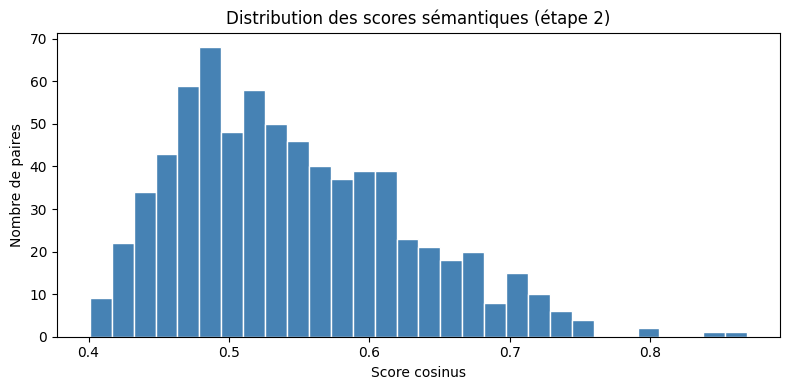

In [7]:
# Distribution des scores sémantiques
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df_candidates["semantic_score"], bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Score cosinus")
plt.ylabel("Nombre de paires")
plt.title("Distribution des scores sémantiques (étape 2)")
plt.tight_layout()
plt.show()

---
## Étape 3 — Matrice de corrélation (heatmap)

Visualisation des similarités cosinus entre toutes les exigences des deux référentiels.  
**Indicatif uniquement** — permet de repérer les clusters de corrélation.

[Étape 3] Heatmap sauvegardée → C:\RiskHunter\referential_mapping\data\outputs\correlation_matrix.png


WindowsPath('C:/RiskHunter/referential_mapping/data/outputs/correlation_matrix.png')

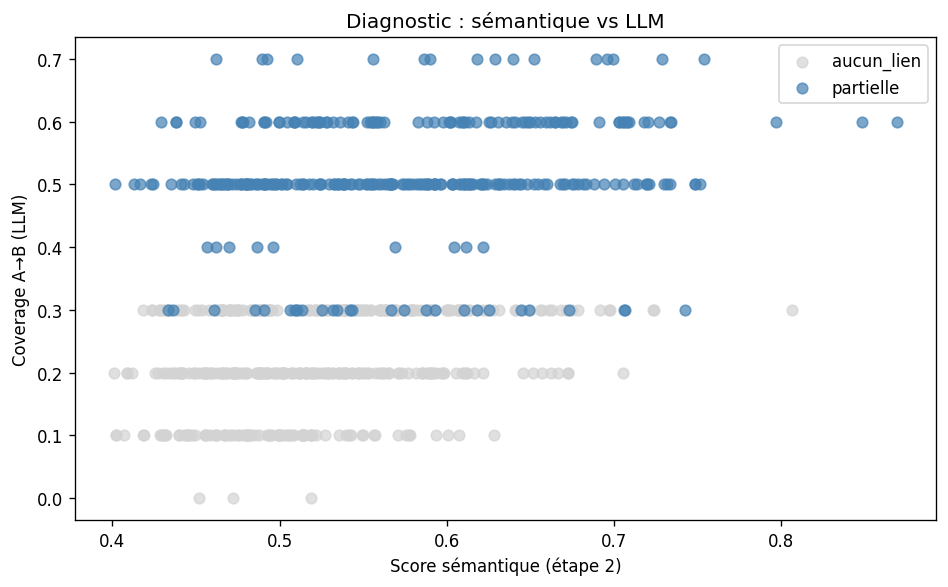

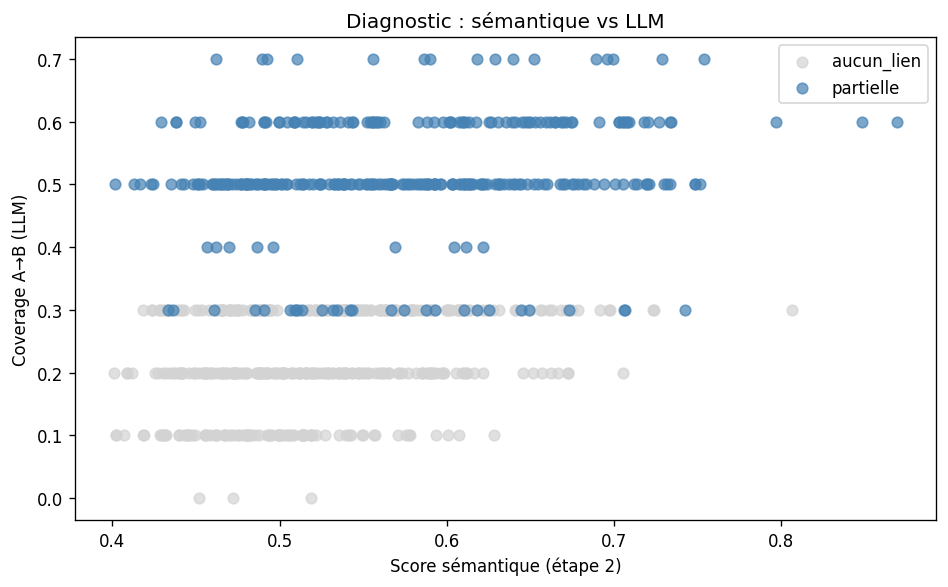

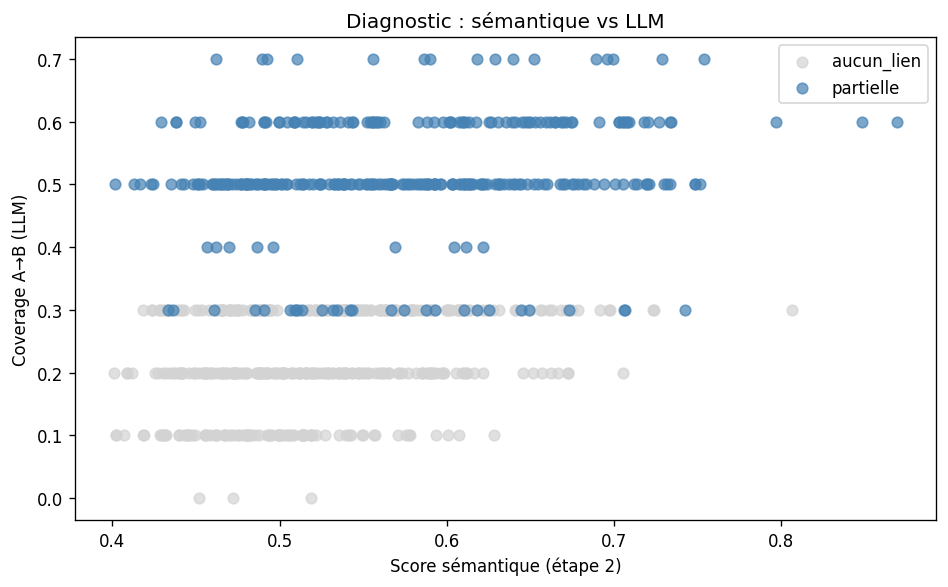

In [16]:
from referential_mapping.visualization.heatmap import run as plot_heatmap

plot_heatmap(ref_A, ref_B, matrix)

---
## Étape 4 — Vérification intelligente LLM

Soumet les paires candidates au LLM (`gpt-4o-mini`) avec **titre + description**.  
Double vérification sur les paires à fort score.  
Export automatique → `mapping_results.xlsx` + `mapping_relations.json`.

> ⚠️ Nécessite une clé `OPENAI_API_KEY` valide (cellule Configuration ci-dessus).

In [26]:
from referential_mapping.llm.scorer import run as score_llm

relations = score_llm(
    candidates, ref_A, ref_B,
        # force=True  # décommenter pour re-scorer même si le cache existe
)

[Étape 4] Cache trouvé — rechargement des relations.
  721 relations chargées depuis le cache.


In [10]:
df_relations = pd.DataFrame([r.to_dict() for r in relations])

print("Répartition par type de relation :")
print(df_relations["relation_type"].value_counts().to_string())
df_relations.sort_values("coverage_A_to_B", ascending=False).head(10)

Répartition par type de relation :
relation_type
aucun_lien    409
partielle     312


,id_A,title_A,id_B,title_B,semantic_score,coverage_A_to_B,coverage_B_to_A,confidence,relation_type
37,CIS-2.5,Logiciels autorisés par Liste d'autorisations,PR.PS-05,L'installation et l'exécution de logiciels non...,0.6995,0.7,0.6,0.8,partielle
289,CIS-17.5,Attribuer des rôles et des responsabilités clés,GV.RR-02,"Les rôles, responsabilités et autorités liés à...",0.5557,0.7,0.6,0.8,partielle
44,CIS-4.1,Établir et maintenir un processus de configura...,PR.PS-01,Des pratiques de gestion de la configuration s...,0.6893,0.7,0.6,0.8,partielle
40,CIS-17.9,Établir et maintenir des seuils d'incidents de...,DE.AE-08,Les incidents sont déclarés lorsque les événem...,0.6957,0.7,0.6,0.8,partielle
616,CIS-13.2,Déployer une solution de détection d'intrusion...,DE.CM-09,"Le matériel et les logiciels informatiques, le...",0.4620,0.7,0.6,0.8,partielle
214,CIS-6.8,Définir et gérer le contrôle d'accès basé sur ...,PR.AA-05,"Les permissions d'accès, les droits et les aut...",0.5861,0.7,0.6,0.8,partielle
130,CIS-1.1,Établir et tenir à jour un inventaire détaillé...,ID.AM-01,Les inventaires du matériel géré par l'organis...,0.6178,0.7,0.6,0.8,partielle
113,CIS-14.9,Organiser une sensibilisation à la sécurité et...,PR.AT-01,Le personnel reçoit une sensibilisation et une...,0.6285,0.7,0.6,0.8,partielle
437,CIS-13.3,Déployer une solution de détection des intrusi...,DE.CM-09,"Le matériel et les logiciels informatiques, le...",0.5105,0.7,0.6,0.8,partielle
101,CIS-14.9,Organiser une sensibilisation à la sécurité et...,PR.AT-02,Les personnes occupant des rôles spécialisés r...,0.6398,0.7,0.6,0.8,partielle


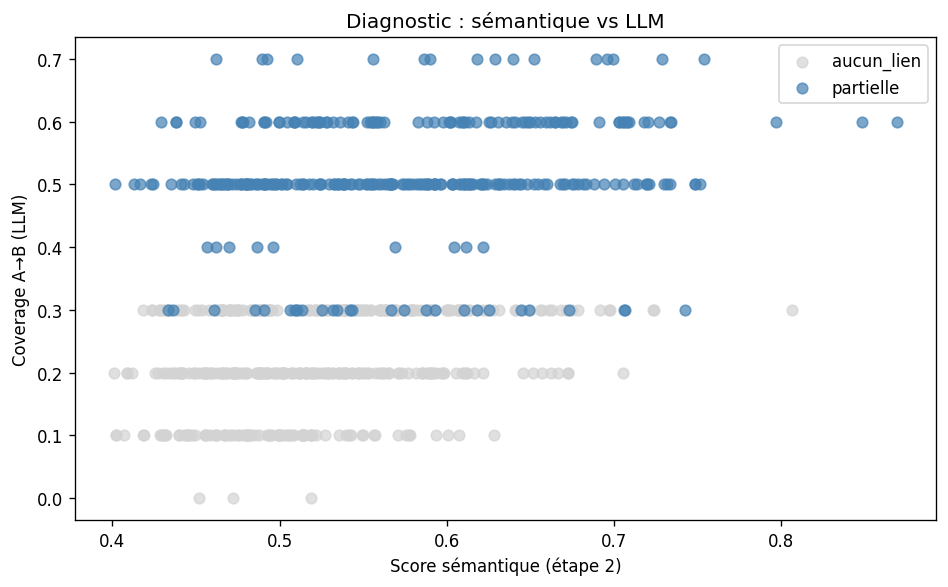

In [17]:
# Diagnostic : score sémantique vs score LLM
fig, ax = plt.subplots(figsize=(8, 5))
colors = {
    "equivalence": "green",
    "A_couvre_B":  "gold",
    "B_couvre_A":  "orange",
    "partielle":   "steelblue",
    "aucun_lien":  "lightgray",
}
for rt, grp in df_relations.groupby("relation_type"):
    ax.scatter(
        grp["semantic_score"],
        grp["coverage_A_to_B"],
        label=rt, alpha=0.7, s=40,
        color=colors.get(rt, "black")
    )
ax.set_xlabel("Score sémantique (étape 2)")
ax.set_ylabel("Coverage A→B (LLM)")
ax.set_title("Diagnostic : sémantique vs LLM")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Filtrer uniquement les mappings significatifs
df_significant = df_relations[df_relations["relation_type"] != "aucun_lien"]
print(f"{len(df_significant)} relations significatives sur {len(df_relations)} scorées")
df_significant.sort_values(["relation_type", "confidence"], ascending=[True, False])

312 relations significatives sur 721 scorées


,id_A,title_A,id_B,title_B,semantic_score,coverage_A_to_B,coverage_B_to_A,confidence,relation_type
3,CIS-2.3,Lutter contre les logiciels non autorisés,PR.PS-05,L'installation et l'exécution de logiciels non...,0.7969,0.6,0.7,0.8,partielle
4,CIS-2.1,Établir et maintenir un inventaire des logiciels,ID.AM-02,"Les inventaires des logiciels, services et sys...",0.7537,0.7,0.6,0.8,partielle
14,CIS-17.8,Réaliser des examens après l'incident,RS.AN-03,Une analyse est effectuée pour établir ce qui ...,0.7283,0.7,0.6,0.8,partielle
37,CIS-2.5,Logiciels autorisés par Liste d'autorisations,PR.PS-05,L'installation et l'exécution de logiciels non...,0.6995,0.7,0.6,0.8,partielle
40,CIS-17.9,Établir et maintenir des seuils d'incidents de...,DE.AE-08,Les incidents sont déclarés lorsque les événem...,0.6957,0.7,0.6,0.8,partielle
...,...,...,...,...,...,...,...,...,...
704,CIS-16.13,Effectuer des tests de pénétration d'applications,ID.RA-01,Les vulnérabilités des actifs sont identifiées...,0.4241,0.5,0.3,0.7,partielle
707,CIS-4.10,Appliquer le verrouillage automatique des appa...,PR.AA-03,"Les utilisateurs, services et matériels sont a...",0.4231,0.5,0.3,0.7,partielle
711,CIS-4.10,Appliquer le verrouillage automatique des appa...,PR.AA-01,Les identités et les informations d'identifica...,0.4167,0.5,0.3,0.7,partielle
712,CIS-16.14,Modélisation de la menace,GV.PO-02,La politique de gestion des risques de cybersé...,0.4128,0.5,0.3,0.7,partielle
